In [1]:
from pymongo import MongoClient
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns

In [2]:
client = MongoClient("mongodb://localhost:27017/")
db = client["boston_housing"]

In [3]:
# total approved construction permits per year in the past ten years

permits_yrly = [{'$match':{'issued_date': {'$ne': None},
                          'permittypedescr': 'Erect/New Construction', # filter only for new buildings
                          'occupancytype': {"$in": ["1-2FAM", "1-3FAM", "1-4FAM", "Multi", "7More"]}}}, # filter for residential units
              {'$project': {'year':{'$year': '$issued_date'}}}, 
              {'$match':{'year': {'$gte': 2015, '$lte': 2025}}}, # last ten years
              {'$group': {
                  '_id': '$year',
                  'total_permits': {'$sum':1}}},
              {'$sort': {'_id': 1}}]

results = list(db['permits'].aggregate(permits_yrly))
results

[{'_id': 2015, 'total_permits': 180},
 {'_id': 2016, 'total_permits': 169},
 {'_id': 2017, 'total_permits': 173},
 {'_id': 2018, 'total_permits': 139},
 {'_id': 2019, 'total_permits': 110},
 {'_id': 2020, 'total_permits': 113},
 {'_id': 2021, 'total_permits': 137},
 {'_id': 2022, 'total_permits': 146},
 {'_id': 2023, 'total_permits': 136},
 {'_id': 2024, 'total_permits': 103},
 {'_id': 2025, 'total_permits': 151}]

In [4]:
# rent prices over time

ovr_time = {}
for doc in db['rent_prices'].find():
    for r in doc['rent_history']:
        date = r['date']
        if date not in ovr_time:
            ovr_time[date] = []
        ovr_time[date].append(r['rent'])

dates = sorted(ovr_time.keys())
avg_rents = [sum(ovr_time[d])/len(ovr_time[d]) for d in dates]

In [5]:
years = [r['_id'] for r in results]
counts = [r['total_permits'] for r in results]

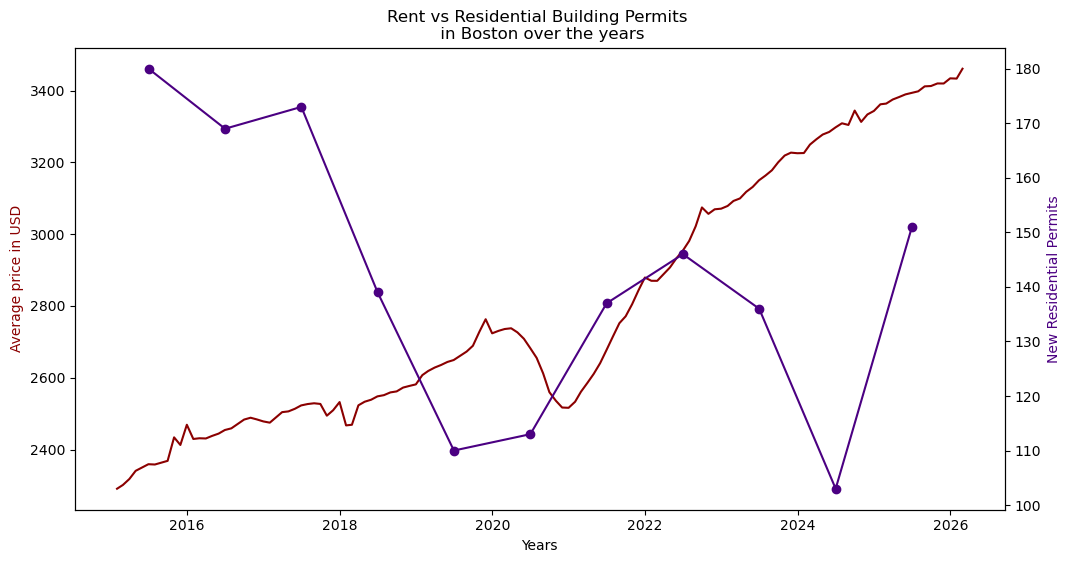

In [16]:
# ai to help me figure out the double axis. the datetime for the x axis kept making the x axis weird. 

fig, ax1 = plt.subplots(figsize=(12, 6))

# rent plot
ax1.plot(dates, avg_rents, label='Average Rent', color='darkred')
ax1.set_xlabel('Years')
ax1.set_ylabel('Average price in USD', color='darkred')
ax1.tick_params(axis='y')

# Convert years to datetime so they align with rent dates
permit_dates = [datetime(y, 7, 1) for y in years]

# prices plot
ax2 = ax1.twinx()
ax2.plot(permit_dates, counts, marker='o', color='indigo', label='New Construction Permits')
ax2.set_ylabel('New Residential Permits', color='indigo')
ax2.tick_params(axis='y')

plt.title('Rent vs Residential Building Permits \n in Boston over the years')
plt.savefig('vis1.png')
plt.show()

In [7]:
# which zipcode had the most change over the years

change = []
for doc in db['rent_prices'].find():
    history = doc['rent_history']
    r1 =  history[0]['rent']
    r2 = history[-1]['rent']
    pct = round(((r2 - r1) / r1) * 100, 2)
    change.append({'zip': doc['zip'], '2015': r1, '2025': r2, 'pct change': pct, 'months': len(history)})

change.sort(key=lambda x: x['pct change'], reverse=True)

In [8]:
# had AI help in presenting the print outcome better

print(f"{'Rank':<6}{'ZIP':<8}{'Start Rent($)':>12} {'Current Rent($)':>14}{'Change':>8}{'Months':>8}")
print("-" * 58)
for i, r in enumerate(change, 1):
    print(f"{i:<6}{r['zip']:<8} {r['2015']:>10,.2f} {r['2025']:>12,.2f} {r['pct change']:>+9.1f}% {r['months']:>7}")

Rank  ZIP     Start Rent($) Current Rent($)  Change  Months
----------------------------------------------------------
1     02120      2,993.90     5,318.25     +77.6%     125
2     02127      2,154.80     3,726.18     +72.9%     134
3     02128      1,850.79     3,036.72     +64.1%     123
4     02130      1,972.70     3,210.37     +62.7%     134
5     02119      2,401.32     3,845.66     +60.1%     101
6     02124      1,904.32     3,039.32     +59.6%      97
7     02122      1,879.76     2,961.11     +57.5%      96
8     02135      1,945.89     3,043.39     +56.4%     134
9     02134      2,033.95     3,134.25     +54.1%     134
10    02131      1,904.49     2,929.73     +53.8%     101
11    02113      2,208.32     3,370.74     +52.6%     134
12    02108      2,114.78     3,217.08     +52.1%     110
13    02129      2,161.27     3,283.25     +51.9%     134
14    02215      2,337.41     3,510.36     +50.2%     134
15    02118      2,753.56     4,093.74     +48.7%     134
16    02115

In [9]:
# zip codes with the most permits. are the zipcodes that have the highest rent increase the same as the ones 
# building the most new residential units?

permits_zip = [{'$match': {'issued_date': {'$ne': None},
                           'permittypedescr': 'Erect/New Construction',
                           'occupancytype': {"$in": ["1-2FAM", "1-3FAM", "1-4FAM", "Multi", "7More"]}}},
               {'$group': {
                   '_id': '$zip',
                   'total_permits': {'$sum':1}}},
               {'$sort': {'total_permits': -1}}]
permits_zip = list(db['permits'].aggregate(permits_zip))

In [10]:
# same using AI to display this better
print(f"{'Rank':<6}{'ZIP':<8}{'Permits':>10}")
print("-" * 24)
for i, r in enumerate(permits_zip, 1):
    print(f"{i:<6}{r['_id']:<8}{r['total_permits']:>10}")

Rank  ZIP        Permits
------------------------
1     02127          256
2     02128          228
3     02132          223
4     02124          218
5     02130          152
6     02131          150
7     02136          149
8     02125          116
9     02121          114
10    02129          108
11    02119          100
12    02135           99
13    02122           89
14    02126           69
15    02120           26
16    02134           24
17    02118            9
18    02116            7
19    02467            2
20    02210            2
21    02215            2
22    02115            1
23    02114            1
24    02113            1
25    02111            1


In [11]:
# combine existing results for plot
scatter_plt = []
permit_plt = {r['_id']: r['total_permits'] for r in permits_zip}

for r in change:
    z = r['zip']
    scatter_plt.append({
        'zip': z,
        'permits': permit_plt.get(z, 0),
        'pct_change': r['pct change']
    })

scatter_plt

[{'zip': '02120', 'permits': 26, 'pct_change': 77.64},
 {'zip': '02127', 'permits': 256, 'pct_change': 72.92},
 {'zip': '02128', 'permits': 228, 'pct_change': 64.08},
 {'zip': '02130', 'permits': 152, 'pct_change': 62.74},
 {'zip': '02119', 'permits': 100, 'pct_change': 60.15},
 {'zip': '02124', 'permits': 218, 'pct_change': 59.6},
 {'zip': '02122', 'permits': 89, 'pct_change': 57.53},
 {'zip': '02135', 'permits': 99, 'pct_change': 56.4},
 {'zip': '02134', 'permits': 24, 'pct_change': 54.1},
 {'zip': '02131', 'permits': 150, 'pct_change': 53.83},
 {'zip': '02113', 'permits': 1, 'pct_change': 52.64},
 {'zip': '02108', 'permits': 0, 'pct_change': 52.12},
 {'zip': '02129', 'permits': 108, 'pct_change': 51.91},
 {'zip': '02215', 'permits': 2, 'pct_change': 50.18},
 {'zip': '02118', 'permits': 9, 'pct_change': 48.67},
 {'zip': '02115', 'permits': 1, 'pct_change': 47.39},
 {'zip': '02116', 'permits': 7, 'pct_change': 45.45},
 {'zip': '02125', 'permits': 116, 'pct_change': 40.43},
 {'zip': '0

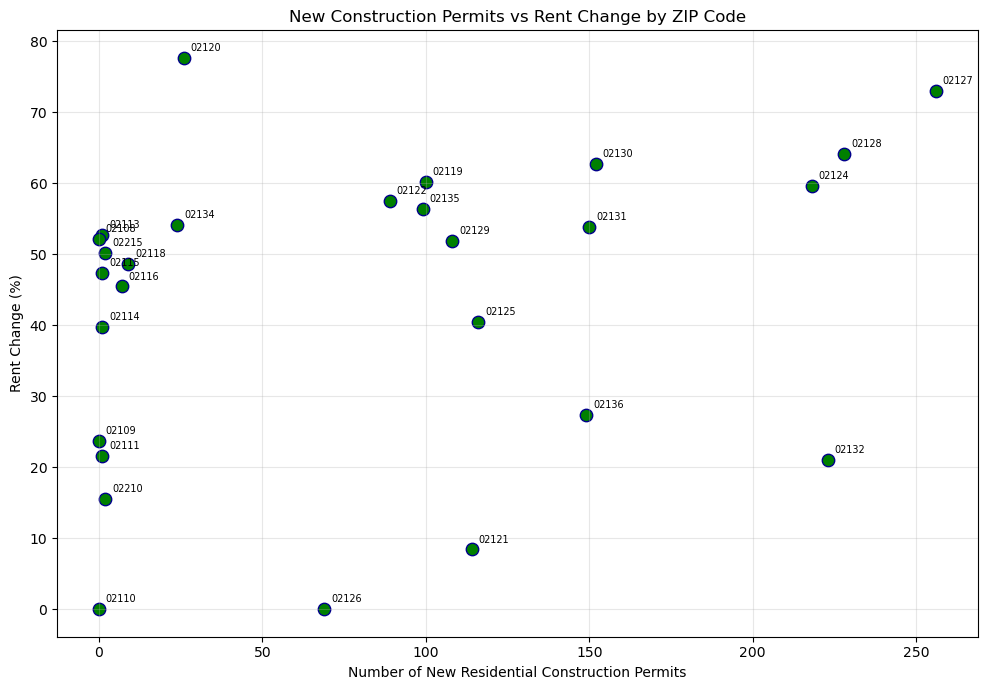

In [17]:
# scatter plot
plt.figure(figsize=(10, 7))
for d in scatter_plt:
    plt.scatter(d['permits'], d['pct_change'], s=80, color='green', edgecolors='darkblue')
    plt.annotate(d['zip'], (d['permits'], d['pct_change']), fontsize=7, xytext=(5, 5), textcoords='offset points')

plt.title('New Construction Permits vs Rent Change by ZIP Code')
plt.xlabel('Number of New Residential Construction Permits')
plt.ylabel('Rent Change (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('viz2.png')
plt.show()

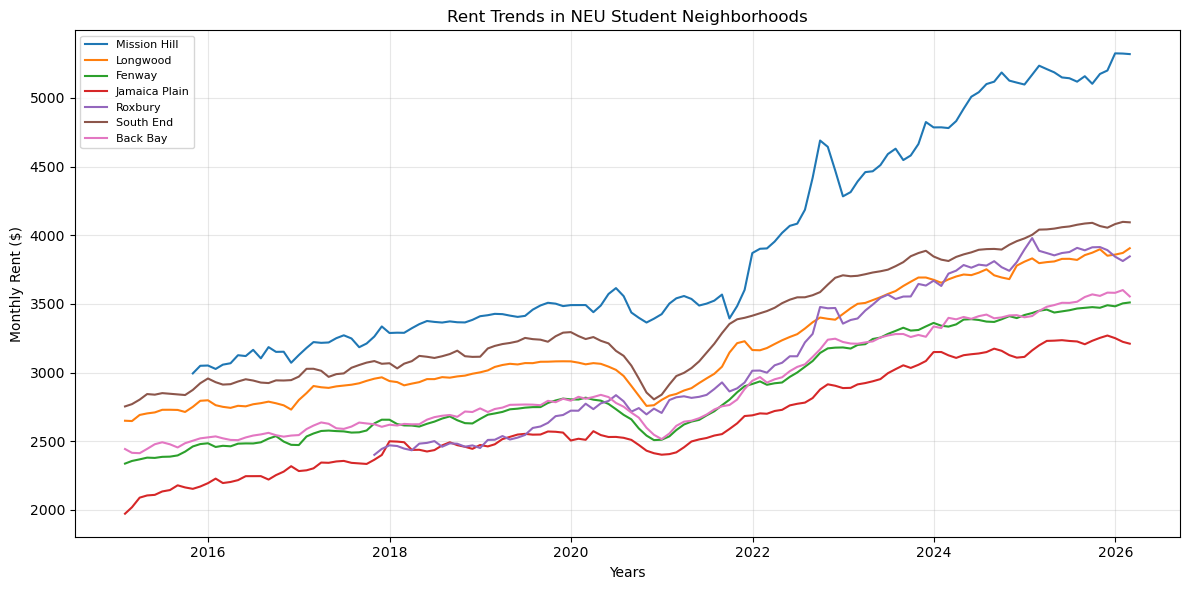

In [18]:
# rent prices over time, highlighting neu student areas
# i debated adding brighton and allston but i feel like there's less neu undergrads there??
# if i was doing students in general i probably would have because of BU in that area

neu_zips = {
    '02120': 'Mission Hill', '02115': 'Longwood', '02215': 'Fenway',
    '02130': 'Jamaica Plain', '02119': 'Roxbury', '02118': 'South End',
    '02116': 'Back Bay'} 

plt.figure(figsize=(12, 6))
for z, name in neu_zips.items():
    doc = db['rent_prices'].find_one({'zip': z})
    if doc and doc['rent_history']:
        dates_z = [r['date'] for r in doc['rent_history']]
        rents_z = [r['rent'] for r in doc['rent_history']]
        plt.plot(dates_z, rents_z, label=name)

plt.title('Rent Trends in NEU Student Neighborhoods')
plt.xlabel('Years')
plt.ylabel('Monthly Rent ($)')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('viz3.png')
plt.show()